<a href="https://colab.research.google.com/github/MaryamNourii/ECG-Signals/blob/Preprocessing/ECG_Denoising_Butterworth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip '/content/drive/MyDrive/ecg/mit-bih-arrhythmia-database-1.0.0.zip'

In [66]:
!pip install wfdb

In [67]:
!pip install matplotlib

In [16]:
import wfdb
import numpy as np
from matplotlib import pyplot as plt
import glob
from scipy import fftpack, signal

In [7]:
fName= '/content/mit-bih-arrhythmia-database-1.0.0/'
fNames = glob.glob(fName + '*.dat')
fNames[0]

'/content/mit-bih-arrhythmia-database-1.0.0/205.dat'

In [14]:
fN = fNames[0].split('.dat')[0]
signals, fileds = wfdb.rdsamp(fN)
annotation = wfdb.rdann(fN, 'atr')
fs = annotation.fs
pos = annotation.sample
lbls = annotation.symbol

/content/mit-bih-arrhythmia-database-1.0.0/205.dat /content/mit-bih-arrhythmia-database-1.0.0/205


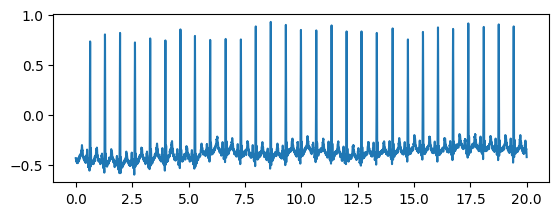

In [60]:
sig = np.array(signals[:,0], dtype = np.float64)

fmax = (fs/2)
L= sig.shape[0]
T= L/fs
t= np.linspace(0,T,L)

n= 20*fs

plt.subplot(2,1,1)
plt.plot(t[:n],sig[:n])
plt.show()


In [61]:
b,a = signal.butter(N=3, Wn=np.array([0.5, 40])/fmax, btype='bandpass')

**Remove Powerline and Baseline wandering noise**

In [62]:
B = fftpack.fft(b, L, axis = 0 )
A = fftpack.fft(a, L, axis = 0 )
fx = fftpack.fft(sig, L, axis = 0 )
H = np.divide(B, A)
Fx = np.multiply(H, fx)
sig_new = fftpack.ifft(Fx, L, axis = 0 )


array([-0.01001044+2.50985557e-17j,  0.02208008+2.54456285e-17j,
        0.02610444+7.14915306e-17j, ..., -0.05147966-5.39246476e-17j,
       -0.04743339-4.76245476e-17j, -0.03782156-3.09821440e-17j])

In [63]:
H.shape, Fx.shape, sig_new.shape

((650000,), (650000,), (650000,))

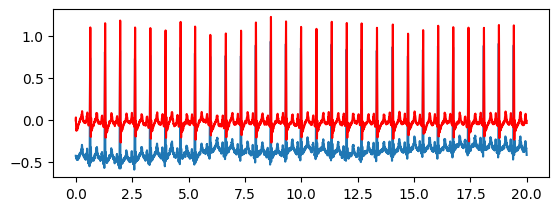

In [64]:
plt.subplot(2,1,1)
plt.plot(t[:n],sig[:n])
plt.plot(t[:n],sig_new[:n], 'r')
plt.show()

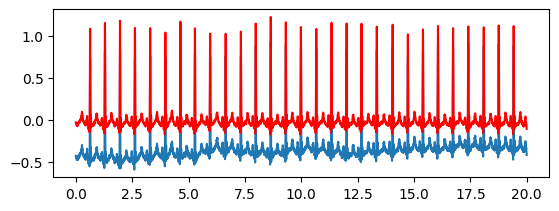

In [65]:
sig_new= signal.filtfilt(b,a,sig,axis=0)

plt.subplot(2,1,1)
plt.plot(t[:n],sig[:n])
plt.plot(t[:n],sig_new[:n], 'r')
plt.show()